Using device: cuda
Using parameters: input_dim=60, seq_len=4
Model loaded from britd_model.pth (Size: 1.22 MB)
Input dimension: 60
Insider user IDs for CERT v6.2 (scenarios ignored): ['BMM0462', 'BPN3051', 'CHB1062', 'CDE1846']
Number of insiders in data: 4 out of 4000 users
Sample common_index (first 5): ['DNS1758', 'ANC1950', 'SAB1954', 'LIM1718', 'LSN1672']
y_true sample (first 5): [0 0 0 0 0]
Insider BMM0462 found in common_index at index 3422
Insider BPN3051 found in common_index at index 320
Insider CHB1062 found in common_index at index 309
Insider CDE1846 found in common_index at index 3649
Selected threshold: 0.310978 (maximized F1-score: 0.320)

Insider Status:
User BMM0462: Error=1.461435, Anomaly=True
User BPN3051: Error=1.148939, Anomaly=True
User CHB1062: Error=1.059639, Anomaly=True
User CDE1846: Error=6.764018, Anomaly=True
User CHB1062: Error=1.059639, Anomaly=True

Performance Metrics:
Mean Reconstruction Error (MSE): 0.014252
Std of Reconstruction Errors: 0.118690
An

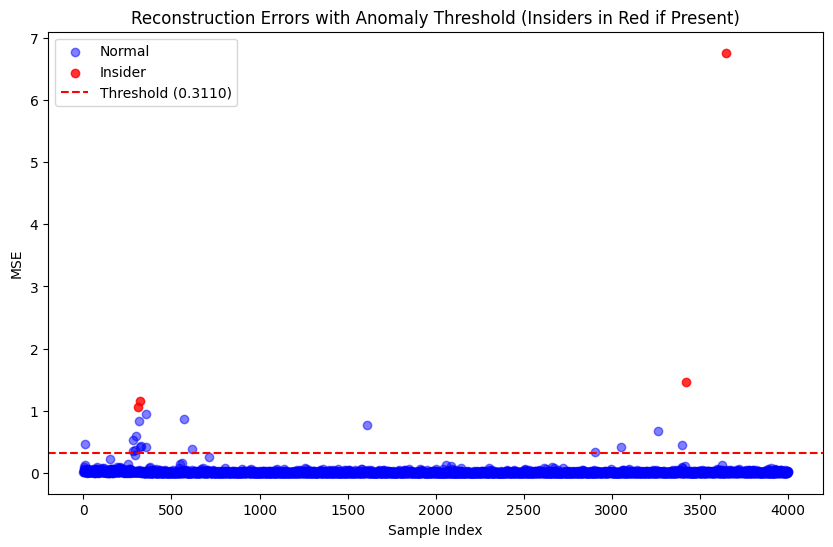


Detected 21 anomalies
Top 5 anomalies (index, user_id, error):
Index 11: User SDH2394, Error: 0.455865
Index 281: User CAG2442, Error: 0.519608
Index 282: User WSA1765, Error: 0.348400
Index 294: User IKP1047, Error: 0.365356
Index 297: User KEF1057, Error: 0.587235
Index 309: User CHB1062 (Insider), Error: 1.059639
Index 313: User KAC1774, Error: 0.832649
Index 320: User BPN3051 (Insider), Error: 1.148939
Index 322: User EPI3052, Error: 0.412154
Index 327: User DLM2440, Error: 0.425971
Index 353: User BPD2437, Error: 0.413253
Index 356: User QGH0041, Error: 0.943759
Index 570: User LAF1796, Error: 0.864139
Index 614: User JCB3054, Error: 0.380470
Index 1609: User ISH0051, Error: 0.763594
Index 2902: User LEB1764, Error: 0.327702
Index 3054: User MAB1775, Error: 0.421209
Index 3264: User LCW0047, Error: 0.667776
Index 3399: User QAH0048, Error: 0.438900
Index 3422: User BMM0462 (Insider), Error: 1.461435
Index 3649: User CDE1846 (Insider), Error: 6.764018

Example anomaly (Index 11, U

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, accuracy_score
import os
import matplotlib.pyplot as plt
import pickle
import time

# Model classes (unchanged)
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, latent_dim):
        super(Encoder, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        latent = self.fc(torch.mean(lstm_out, dim=1))
        return latent

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, seq_len):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        self.output_dim = output_dim
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim * seq_len)
        )

    def forward(self, x):
        reconstructed = self.fc(x)
        reconstructed = reconstructed.view(-1, self.seq_len, self.output_dim)
        return reconstructed

class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Preprocess new data (with debugging)
def preprocess_new_data(csv_files, expected_input_dim, insiders_file="insiders.csv"):
    try:
        dataframes = [pd.read_csv(file, index_col='Unnamed: 0') for file in csv_files]
    except FileNotFoundError as e:
        raise FileNotFoundError(f"CSV file not found: {e}")

    common_index = dataframes[0].index
    for df in dataframes[1:]:
        common_index = common_index.intersection(df.index)
    if len(common_index) == 0:
        raise ValueError("No common indices found across CSV files.")
    dataframes = [df.loc[common_index] for df in dataframes]

    data = np.stack([df.values for df in dataframes], axis=1)
    actual_input_dim = data.shape[-1]
    if actual_input_dim != expected_input_dim:
        raise ValueError(f"Input dimension mismatch: got {actual_input_dim}, expected {expected_input_dim}")
    print(f"Input dimension: {actual_input_dim}")

    data = np.nan_to_num(data, nan=0.0)

    scaler_file = "scaler.pkl"
    if os.path.exists(scaler_file):
        with open(scaler_file, "rb") as f:
            scaler = pickle.load(f)
    else:
        raise FileNotFoundError(f"Scaler file {scaler_file} not found in {os.getcwd()}")

    data_reshaped = data.reshape(-1, data.shape[-1])
    data_normalized = scaler.transform(data_reshaped).reshape(data.shape)

    # Load insiders.csv, filter for CERT v6.2, and extract unique user IDs (ignoring scenarios)
    try:
        insiders_df = pd.read_csv(insiders_file)
        insiders_v62 = insiders_df[insiders_df['dataset'] == 6.2]['user'].unique().tolist()
        print(f"Insider user IDs for CERT v6.2 (scenarios ignored): {insiders_v62}")
    except FileNotFoundError:
        raise FileNotFoundError(f"Insiders file {insiders_file} not found")
    except KeyError as e:
        raise KeyError(f"Invalid insiders.csv format: missing column {e}")

    # Create y_true: 1 for insiders, 0 for normal users
    y_true = np.array([1 if user in insiders_v62 else 0 for user in common_index])
    print(f"Number of insiders in data: {np.sum(y_true)} out of {len(y_true)} users")
    #print(f"Sample common_index (first 5): {list(common_index[:5])}")
    #print(f"y_true sample (first 5): {y_true[:5]}")
    
    # Check for insider presence
    for insider in insiders_v62:
        if insider in common_index:
            print(f"Insider {insider} found in common_index at index {common_index.get_loc(insider)}")
        else:
            print(f"Insider {insider} NOT found in common_index")
    
    if np.sum(y_true) == 0:
        print("Warning: No insiders found in common_index. Check user ID formats or dataset coverage.")

    return data_normalized, common_index, y_true

# Evaluate reconstruction errors with timing (unchanged)
def evaluate_autoencoder(model, data_tensor, criterion, device):
    model.eval()
    reconstruction_errors = []
    start_time = time.time()
    with torch.no_grad():
        for i in range(len(data_tensor)):
            input_data = data_tensor[i:i+1].to(device)
            output = model(input_data)
            error = criterion(output, input_data).item()
            reconstruction_errors.append(error)
    inference_time = time.time() - start_time
    return reconstruction_errors, inference_time

# Detect anomalies and compute metrics (reinstated AUC-ROC and AUC-PR)
def compute_metrics(reconstruction_errors, common_index, y_true=None, threshold=None):
    # Unsupervised metrics
    mean_error = np.mean(reconstruction_errors)
    std_error = np.std(reconstruction_errors)
    if threshold is None:
        # Try multiple thresholds to maximize F1-score if y_true is provided
        if y_true is not None and len(np.unique(y_true)) > 1:
            thresholds = [mean_error + k * std_error for k in [1.0, 1.5, 2.0, 2.5]]
            best_f1 = 0
            best_threshold = mean_error + 2 * std_error
            for t in thresholds:
                anomaly_flags = [1 if error > t else 0 for error in reconstruction_errors]
                f1 = f1_score(y_true, anomaly_flags, zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = t
            threshold = best_threshold
            print(f"Selected threshold: {threshold:.6f} (maximized F1-score: {best_f1:.3f})")
        else:
            threshold = mean_error + 2 * std_error
    
    anomaly_flags = [1 if error > threshold else 0 for error in reconstruction_errors]
    anomaly_rate = np.mean(anomaly_flags) * 100  # Percentage of anomalies

    metrics = {
        "mean_mse": mean_error,
        "std_mse": std_error,
        "threshold": threshold,
        "anomaly_rate": anomaly_rate
    }

    # Supervised metrics
    if y_true is not None:
        accuracy = accuracy_score(y_true, anomaly_flags)
        precision = precision_score(y_true, anomaly_flags, zero_division=0)
        recall = recall_score(y_true, anomaly_flags, zero_division=0)
        f1 = f1_score(y_true, anomaly_flags, zero_division=0)
        metrics.update({
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

        # Compute AUC metrics only if multiple classes are present
        if len(np.unique(y_true)) > 1:
            auc_roc = roc_auc_score(y_true, reconstruction_errors)
            precision_vals, recall_vals, _ = precision_recall_curve(y_true, reconstruction_errors)
            auc_pr = np.trapz(recall_vals, precision_vals)
            metrics.update({
                "auc_roc": auc_roc,
                "auc_pr": auc_pr
            })
        else:
            print("Warning: Only one class in y_true. AUC-ROC and AUC-PR not computed.")
            metrics.update({
                "auc_roc": None,
                "auc_pr": None
            })

    # Anomalies
    anomalies = [(i, common_index[i], error) for i, error in enumerate(reconstruction_errors) if error > threshold]
    
    # Report insider-specific status
    insider_ids = ['BMM0462', 'BPN3051', 'CHB1062', 'CDE1846', 'CHB1062']
    print("\nInsider Status:")
    for user_id in insider_ids:
        if user_id in common_index:
            idx = common_index.get_loc(user_id)
            error = reconstruction_errors[idx]
            is_anomaly = error > threshold
            print(f"User {user_id}: Error={error:.6f}, Anomaly={is_anomaly}")
        else:
            print(f"User {user_id}: Not found in dataset")

    return metrics, anomalies

# Plot reconstruction errors (handle single-class y_true)
def plot_errors(reconstruction_errors, threshold, y_true, save_path="reconstruction_errors.png"):
    plt.figure(figsize=(10, 6))
    indices = range(len(reconstruction_errors))
    if len(np.unique(y_true)) > 1:
        normal_indices = [i for i, label in enumerate(y_true) if label == 0]
        insider_indices = [i for i, label in enumerate(y_true) if label == 1]
        plt.scatter(normal_indices, [reconstruction_errors[i] for i in normal_indices], c='blue', label="Normal", alpha=0.5)
        plt.scatter(insider_indices, [reconstruction_errors[i] for i in insider_indices], c='red', label="Insider", alpha=0.8)
    else:
        plt.scatter(indices, reconstruction_errors, c='blue', label="Normal", alpha=0.5)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold ({threshold:.4f})")
    plt.xlabel("Sample Index")
    plt.ylabel("MSE")
    plt.title("Reconstruction Errors with Anomaly Threshold (Insiders in Red if Present)")
    plt.legend()
    plt.savefig(save_path)
    plt.show()

# Main function (updated to print AUC metrics)
def main():
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Model path
    model_path = "britd_model.pth"
    model_size = os.path.getsize(model_path) / (1024 ** 2) if os.path.exists(model_path) else 0  # Size in MB

    # Model parameters
    input_dim = 60  # Adjust to 129 if needed
    seq_len = 4
    hidden_dim = 64
    num_layers = 3
    latent_dim = 32
    print(f"Using parameters: input_dim={input_dim}, seq_len={seq_len}")

    # Initialize model
    encoder = Encoder(input_dim, hidden_dim, num_layers, latent_dim)
    decoder = Decoder(latent_dim, input_dim, seq_len)
    autoencoder = Autoencoder(encoder, decoder).to(device)

    # Load model state
    try:
        autoencoder.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Model loaded from {model_path} (Size: {model_size:.2f} MB)")
    except FileNotFoundError:
        raise FileNotFoundError(f"Model file not found at {model_path}")
    except Exception as e:
        raise RuntimeError(f"Failed to load model: {e}")

    # New data
    csv_files = [
        "gran/0_6_token_counts.csv",
        "gran/6_12_token_counts.csv",
        "gran/12_18_token_counts.csv",
        "gran/18_24_token_counts.csv"
    ]

    # Preprocess data
    data_normalized, common_index, y_true = preprocess_new_data(csv_files, input_dim)
    data_tensor = torch.tensor(data_normalized, dtype=torch.float32)

    # Loss function
    criterion = nn.MSELoss()

    # Compute reconstruction errors
    reconstruction_errors, inference_time = evaluate_autoencoder(autoencoder, data_tensor, criterion, device)

    # Compute metrics
    metrics, anomalies = compute_metrics(reconstruction_errors, common_index, y_true)

    # Print metrics
    print("\nPerformance Metrics:")
    print(f"Mean Reconstruction Error (MSE): {metrics['mean_mse']:.6f}")
    print(f"Std of Reconstruction Errors: {metrics['std_mse']:.6f}")
    print(f"Anomaly Threshold: {metrics['threshold']:.6f}")
    print(f"Anomaly Rate: {metrics['anomaly_rate']:.2f}%")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Model Size: {model_size:.2f} MB")
    print(f"Accuracy: {metrics['accuracy']:.3f}")
    print(f"Precision: {metrics['precision']:.3f}")
    print(f"Recall: {metrics['recall']:.3f}")
    print(f"F1-Score: {metrics['f1_score']:.3f}")
    if metrics['auc_roc'] is not None:
        print(f"AUC-ROC: {metrics['auc_roc']:.3f}")
    else:
        print("AUC-ROC: Not computed (single class in y_true)")
    if metrics['auc_pr'] is not None:
        print(f"AUC-PR: {metrics['auc_pr']:.3f}")
    else:
        print("AUC-PR: Not computed (single class in y_true)")

    # Plot errors
    plot_errors(reconstruction_errors, metrics['threshold'], y_true)

    # Report anomalies
    print(f"\nDetected {len(anomalies)} anomalies")
    if anomalies:
        print("Top 5 anomalies (index, user_id, error):")
        for idx, user_id, error in anomalies[:]:
            is_insider = " (Insider)" if user_id in ['BMM0462', 'BPN3051', 'CHB1062', 'CDE1846', 'CHB1062'] else ""
            print(f"Index {idx}: User {user_id}{is_insider}, Error: {error:.6f}")

    # Inspect a sample anomaly
    if anomalies:
        sample_idx = anomalies[0][0]
        autoencoder.eval()
        with torch.no_grad():
            input_sample = data_tensor[sample_idx:sample_idx+1].to(device)
            reconstructed = autoencoder(input_sample)
            print(f"\nExample anomaly (Index {sample_idx}, User {common_index[sample_idx]}):")
            print(f"Input (first 5 features): {input_sample[0, 0, :5].cpu().numpy()}")
            print(f"Output (first 5 features): {reconstructed[0, 0, :5].cpu().numpy()}")

if __name__ == "__main__":
    main()